In [37]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import s3fs
import xarray as xr
import os
import pandas as pd

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [42]:
dis = pd.read_csv('/Users/cjense/Downloads/dataverse_files/sector_D.csv')
dis['Date'] = pd.to_datetime(dis['Date'])

In [43]:
disZI = dis[['Date', 'ZACHARIAE_ISSTROM']]
disZI

,Date,ZACHARIAE_ISSTROM
0,1986-04-15,9.862637
1,1986-05-15,9.941773
2,1986-06-15,10.023547
3,1986-07-15,9.600656
4,1986-08-15,10.526871
...,...,...
2974,2026-05-11,17.148004
2975,2026-05-23,17.135299
2976,2026-06-04,17.153831
2977,2026-06-16,17.344709


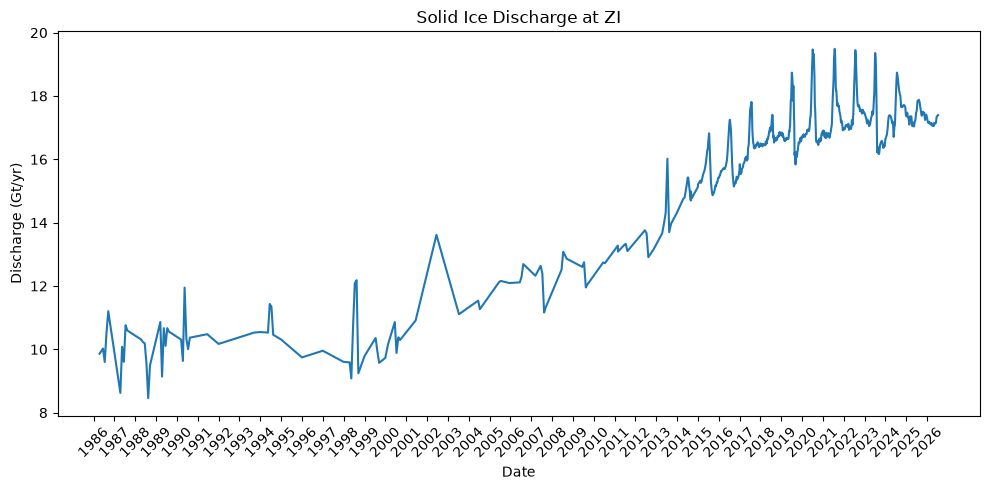

In [50]:
plt.subplots(figsize=(10,5))

plt.plot(disZI['Date'], disZI['ZACHARIAE_ISSTROM'])

years = pd.date_range(
    disZI['Date'].min().replace(month=1, day=1),
    disZI['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at ZI')
plt.tight_layout()
plt.savefig('figures/discharge_ZI.png', dpi=300)
plt.show()

In [45]:
dis79N = dis[['Date', 'NIOGHALVFJERDSFJORDEN']]
dis79N

,Date,NIOGHALVFJERDSFJORDEN
0,1986-04-15,12.511567
1,1986-05-15,12.556251
2,1986-06-15,12.607524
3,1986-07-15,11.101405
4,1986-08-15,12.042042
...,...,...
2974,2026-05-11,13.191789
2975,2026-05-23,13.211337
2976,2026-06-04,13.333079
2977,2026-06-16,13.405305


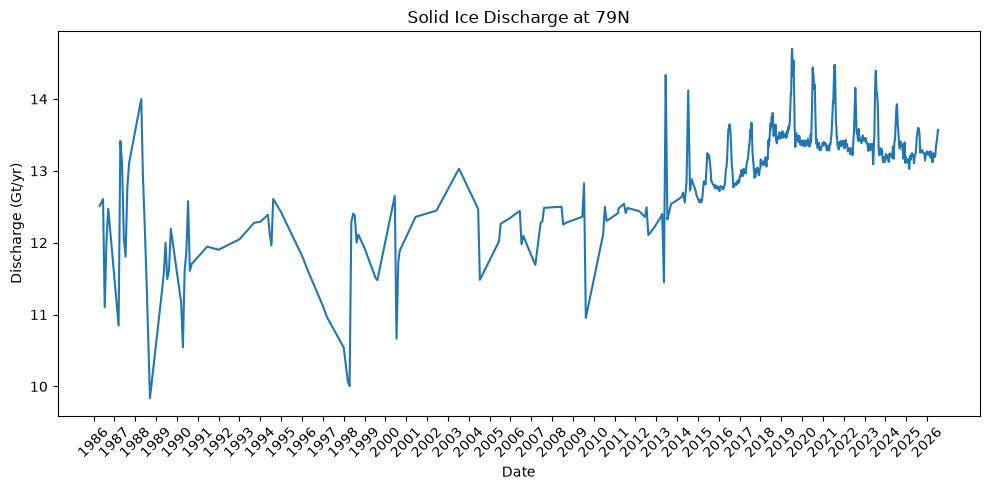

In [49]:
plt.subplots(figsize=(10,5))
plt.plot(dis79N['Date'], dis79N['NIOGHALVFJERDSFJORDEN'])

years = pd.date_range(
    dis79N['Date'].min().replace(month=1, day=1),
    dis79N['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at 79N')
plt.tight_layout()
plt.savefig('figures/discharge_79N.png', dpi=300)
plt.show()